# Analytic Heat Redistribution Testing

In [1]:
import os, sys
import picaso.justdoit as jdi

import warnings
warnings.filterwarnings('ignore')
import picaso.justdoit as jdi
import picaso.justplotit as jpi
import virga.justdoit as vj
import virga.justplotit as cldplt
from bokeh.plotting import show, figure
jpi.output_notebook()
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import ascii
import copy
import pandas as pd
#%matplotlib inline
#mpl.rc_file('/Users/btl756/Desktop/caroline/liberles_rc')

/Users/adityasengupta/picaso/picaso/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import declare_namespace


Loading BokehJS ...

## Create a CO2 profile

First let's create a custom 100% CO2 chemistry profile that we can use to make a "Venus" analog

In [2]:
import picaso

In [3]:
picaso.__version__

AttributeError: module 'picaso' has no attribute '__version__'

In [4]:
#NEB NOT NEEDED
"""# start with grabbing one of channon's chemistry files
channon = ascii.read('/Users/btl756/Desktop/caroline/picaso/reference/chemistry/visscher_grid_2121/sonora_2121grid_feh-0.3_co0.14.txt')

# change compositions in the grabbed file to match 100% CO2 atmosphere
co2_pt_temp = copy.deepcopy(channon)

# cycle through all levels in the atmosphere
for i in range(len(channon['P(bar)'])):    
    for col in channon.colnames:
        if col not in ['P(bar)', 'T(K)']: # only want to change the composition columns
            if col != 'CO2': co2_pt_temp[col][[i]] = 1e-50 # set all compositions to zero except CO2; 1e-50 to avoid division by zero errors

    # update CO2 compostion column
    co2_pt_temp['CO2'][i] = 1

# clean up formatting of our new CO2 PT profile
co2_pt = co2_pt_temp.to_pandas()
co2_pt = co2_pt.rename(columns={'P(bar)': 'pressure', 'T(K)': 'temperature', 'atCs': 'Cs'})
co2_pt['pressure'] = 10**co2_pt['pressure']
co2_pt"""

"# start with grabbing one of channon's chemistry files\nchannon = ascii.read('/Users/btl756/Desktop/caroline/picaso/reference/chemistry/visscher_grid_2121/sonora_2121grid_feh-0.3_co0.14.txt')\n\n# change compositions in the grabbed file to match 100% CO2 atmosphere\nco2_pt_temp = copy.deepcopy(channon)\n\n# cycle through all levels in the atmosphere\nfor i in range(len(channon['P(bar)'])):    \n    for col in channon.colnames:\n        if col not in ['P(bar)', 'T(K)']: # only want to change the composition columns\n            if col != 'CO2': co2_pt_temp[col][[i]] = 1e-50 # set all compositions to zero except CO2; 1e-50 to avoid division by zero errors\n\n    # update CO2 compostion column\n    co2_pt_temp['CO2'][i] = 1\n\n# clean up formatting of our new CO2 PT profile\nco2_pt = co2_pt_temp.to_pandas()\nco2_pt = co2_pt.rename(columns={'P(bar)': 'pressure', 'T(K)': 'temperature', 'atCs': 'Cs'})\nco2_pt['pressure'] = 10**co2_pt['pressure']\nco2_pt"

## Load opacities

In [6]:
os.environ['picaso_refdata']

'/Users/adityasengupta/picaso/reference/'

In [7]:
import os;import glob
[i.split('/')[-1].split("_")[0] for i in glob.glob(
    os.path.join(os.environ['picaso_refdata'],'climate_INPUTS','ktable_by_molecule','*npy')
)]

[]

In [10]:
import json

In [11]:
inputs = json.load(open(os.path.join(os.environ['picaso_refdata'],'config.json')))

In [12]:
inputs

{'version': '4.0',
 'calculation': 'spectrum_only',
 'phase': 0,
 'planet': {'gravity': None,
  'gravity_unit': None,
  'radius': None,
  'radius_unit': None,
  'mass': None,
  'mass_unit': None},
 'climate': {'t_table': None,
  'p_table': None,
  'grad': None,
  'cp': None,
  'guess_temp': None,
  'pressure': None,
  'nstr': None,
  'nofczns': None,
  'rfacv': None,
  'rfaci': None},
 'star': {'database': 'ck04models', 'temp': None, 'metal': None, 'logg': None},
 'atmosphere': {'profile': None,
  'exclude_mol': 1,
  'pt_params': None,
  'mh': None,
  'cto': None},
 'clouds': {'profile': None,
  'wavenumber': None,
  'scattering': {'g0': None, 'w0': None, 'opd': None},
  'do_holes': False},
 'approx': {'get_layer_fluxes': 0,
  'p_reference': 1,
  'rt_method': 'toon',
  'rt_params': {'toon': {'toon_coefficients': 0,
    'multi_phase': 0,
    'single_phase': 3},
   'SH': {'single_form': 0,
    'w_single_form': 0,
    'w_multi_form': 0,
    'psingle_form': 0,
    'w_single_rayleigh': 1,
 

In [13]:
# set up on-the-fly opacities
import os;import glob
[i.split('/')[-1].split("_")[0] for i in glob.glob(
    os.path.join(os.environ['picaso_refdata'],'climate_INPUTS','ktable_by_molecule','*npy')
)]
#should see a list of molecules (ie. ['H3+', 'FeH', 'C2H2'....])

#gases_fly = ['CO','CH4','H2O','NH3','CO2','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']
gases_fly = ['H2', 'He', 'H2O', 'CO2', 'CO', 'NH3', 'CH4', 'Na', 'K']
opacity_fly = jdi.opannection(method = 'resampled', preload_gases=gases_fly)
opacity_fly.delta_wno = []
for i in range(len(opacity_fly.wno) - 1):
    opacity_fly.delta_wno.append(float(opacity_fly.wno[i+1]-opacity_fly.wno[i]))
#NEB NOT NEEDED 
# opacity_fly.full_abunds = co2_pt # set the abundances to the CO2 profile

## Run a planet with constant rfacv (the old way with no changes to the code)

In [14]:
float(opacity_fly.wno[i+1]-opacity_fly.wno[i])

2.22209630029829

In [18]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260#110 # Intrinsic Temperature in K; inputting venus equilibrium temperature
grav = 8.87#24.79 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

# now let's input host-star properties
T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723#5.2 # star planet distance, AU

cl_run.star(opacity_fly, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# make an initial T(P) guess
nlevel = 91 # number of plane-parallel levels in your code

Teq = 260#122 # venus equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

# make assumptions for surface reflectance
albedo = 0.4 # assume some albedo to set surface properties
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1)) # not currently compatible with on-the-fly opacities

rfacv = 0.5

# gather inputs for our climate run
cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=74, rfacv=rfacv)

# prepare opacities for on-the-fly mixing
#NEB NOT NEEDED 
# exclude_mol = ['CO','CH4','H2O','NH3','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']

#cl_run.chemistry_handler(chemistry_table=co2_pt)
#cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
#cl_run.premix_atmosphere(opa=opacity_fly)
pt['CO2']=1.0
pt['H2']=1e-50
cl_run.atmosphere(df=pt, chem_method='fixed',quench=False, mh=0.0, cto_absolute=0.46)


# run the climate code!
# NEB CHANGED DISEQ_CHEM=FALSE
out_const_rfacv = cl_run.climate(opacity_fly, save_all_profiles=True, with_spec=True, diseq_chem=False)

Exception: A chem option fixed is not valid.

In [4]:
opacity_fly.temps

array([], dtype=object)

Analyze output in xarray

In [5]:
preserve_clima_const_rfacv = jdi.output_xarray(out_const_rfacv, cl_run)#, savefile='venus_co2_pt.nc')
preserve_clima_const_rfacv

<xarray.Dataset> Size: 134kB
Dimensions:         (pressure: 91, pressure_layer: 90, wavelength: 661)
Coordinates:
  * pressure        (pressure) float64 728B 1e-06 1.292e-06 ... 7.743e+03 1e+04
  * pressure_layer  (pressure_layer) float64 720B 1.136e-06 ... 8.799e+03
  * wavelength      (wavelength) float64 5kB 267.6 197.9 154.9 ... 0.287 0.2679
Data variables: (12/169)
    temperature     (pressure) float64 728B 240.3 233.1 ... 1.581e+03 1.694e+03
    dtdp            (pressure_layer) float64 720B -0.119 -0.1658 ... 0.2695
    guess 1         (pressure) float64 728B 263.2 263.2 ... 5.548e+03 5.915e+03
    guess 2         (pressure) float64 728B 263.2 263.2 ... 4.751e+03 4.971e+03
    guess 3         (pressure) float64 728B 263.2 263.2 ... 4.751e+03 4.971e+03
    guess 4         (pressure) float64 728B 261.5 261.3 ... 4.72e+03 4.939e+03
    ...              ...
    guess 162       (pressure) float64 728B 240.4 233.2 ... 1.586e+03 1.699e+03
    guess 163       (pressure) float64 728B 240.3 233.1 ... 1.582e+03 1.695e+03
    guess 164       (pressure) float64 728B 240.3 233.1 ... 1.581e+03 1.694e+03
    flux_emission   (wavelength) float64 5kB 3.281e+04 1.079e+05 ... 3.914e-19
    CO2             (pressure) float64 728B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    H2              (pressure) float64 728B 1e-50 1e-50 1e-50 ... 1e-50 1e-50
Attributes:
    climate_params:  {"cvs_locs": [0, 67, 69, 69, 74, 89], "converged": 1}
    planet_params:   {"effective_temp": 302.77051433709215, "gravity": {"valu...
    stellar_params:  {"database": "phoenix", "steff": 5800, "feh": 0.012, "lo...
    orbit_params:    {"sma": {"value": 10815926051610.0, "unit": "cm"}}

In [6]:
# save xarray to txt file
#preserve_clima_const_rfacv.to_dataframe().to_csv('venus_co2_ptprofile.txt', sep='\t')

Plot PT profile

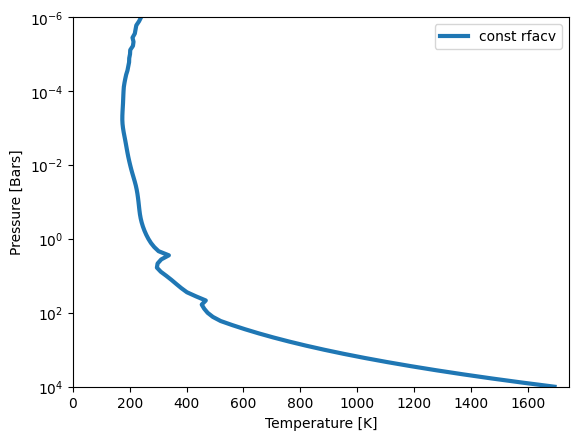

In [7]:
plt.semilogy(out_const_rfacv['temperature'], out_const_rfacv['pressure'],linewidth=3,label="const rfacv")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
plt.ylim(1e4,1e-6)
plt.xlim(0, out_const_rfacv['temperature'].max() + 50)
plt.legend()

Check the brightness temperature

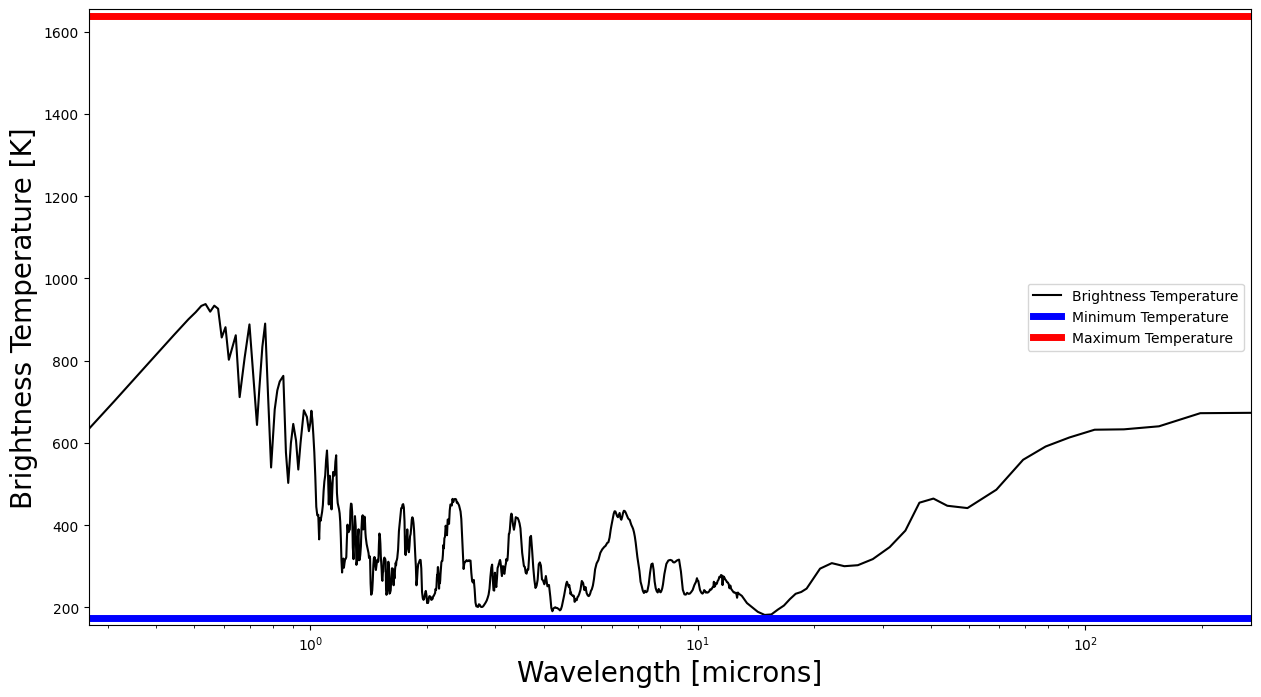

In [8]:
brightness_temp, figure= jpi.brightness_temperature(out_const_rfacv['spectrum_output'])

Evaluate the adiabat

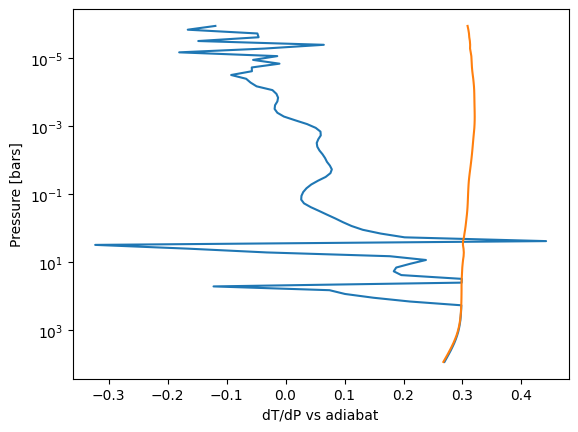

In [9]:
cp, adiabat, dtdp, pressure = jpi.pt_adiabat(out_const_rfacv, cl_run, opacity_fly, plot=True)
# blue is dT/dP, orange is the gradient of the adiabat

## Run a planet with analytic heat redistribution (involving the new changes to the code)

The only difference between the cell below and what was run for the old code case above is setting rfacv = 'analytic'

In [ ]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260#110 # Intrinsic Temperature in K; inputting venus equilibrium temperature
grav = 8.87#24.79 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

# now let's input host-star properties
T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723#5.2 # star planet distance, AU

cl_run.star(opacity_fly, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# make an initial T(P) guess
nlevel = 91 # number of plane-parallel levels in your code

Teq = 260#122 # venus equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

# make assumptions for surface reflectance
albedo = 0.4 # assume some albedo to set surface properties
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1)) # not currently compatible with on-the-fly opacities

rfacv = 'analytic' # set rfacv to analytic to enable analytic heat redistribution

# gather inputs for our climate run
cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=74, rfacv=rfacv)

#NEB NOT NEEDED
# prepare opacities for on-the-fly mixing
#exclude_mol = ['CO','CH4','H2O','NH3','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']

#cl_run.chemistry_handler(chemistry_table=co2_pt)
#cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
#cl_run.premix_atmosphere(opa=opacity_fly)

pt['CO2']=1.0
pt['H2']=1e-50
cl_run.atmosphere(df=pt, chem_method='fixed',quench=False)


# run the climate code!
# NEB CHANGED DISEQ_CHEM=FALSE

out_analytic_rfacv = cl_run.climate(opacity_fly, save_all_profiles=True, with_spec=True, diseq_chem=False)

SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
I am updating rfacv.
I dont have fluxes, let me compute them
Iteration number  0 , min , max temp  259.6566017080999 4939.477448895725 , flux balance  88.08203897684494
Iteration number  1 , min , max temp  204.27050130993302 4451.870384928938 , flux balance  29.70909309906726
Iteration number  2 , min , max temp  179.75759023204543 4073.7550411106927 , flux balance  9.888532839338495
Iteration number  3 , min , max temp  165.55780635621608 3761.3966038055646 , flux balance  3.1540644179208615
Iteration number  4 , min , max temp  99.34525413911418 3490.7744120318603 , flux balance  0.9376856025290687
Iteration number  5 , min , max temp  172.40305822447988 3258.2988328499464 , flux balance  0.36227539845951523
Iteration number  6 , min , max temp  19.026092605521654 3072.447512186635 , flux balance  0.10767002883686437
Iteration number  7 , min , max temp  10.1 2950.331120775

Analyze output in xarray

In [ ]:
preserve_clima_analytic_rfacv = jdi.output_xarray(out_analytic_rfacv, cl_run)
preserve_clima_analytic_rfacv

Plot PT profile

In [ ]:
plt.semilogy(out_analytic_rfacv['temperature'], out_analytic_rfacv['pressure'],linewidth=3,label="analytic rfacv")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
plt.ylim(1e4,1e-6)
plt.xlim(0, out_analytic_rfacv['temperature'].max() + 50)
plt.legend()

Check the brightness temperature

In [ ]:
brightness_temp, figure= jpi.brightness_temperature(out_analytic_rfacv['spectrum_output'])

Evaluate the adiabat

In [ ]:
cp, adiabat, dtdp, pressure = jpi.pt_adiabat(out_analytic_rfacv, cl_run, opacity_fly, plot=True)
# blue is dT/dP, orange is the gradient of the adiabat

Compare PT Profiles

In [ ]:
plt.semilogy(out_const_rfacv['temperature'], out_const_rfacv['pressure'], label="const rfacv")
plt.semilogy(out_analytic_rfacv['temperature'], out_analytic_rfacv['pressure'], label="analytic rfacv")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
plt.ylim(1e4,1e-6)
plt.xlim(0, out_analytic_rfacv['temperature'].max() + 50)
plt.legend()

Let's take a look at the rfacv values

In [ ]:
out_analytic_rfacv['all_rfacv']

In [ ]:
# plot the evolution of rfacv over the model run
all_rfacv = out_analytic_rfacv['all_rfacv']
x = np.arange(0, len(all_rfacv), 1)
plt.plot(x, all_rfacv)
plt.xlabel('Model Iteration')
plt.ylabel('$f$')

## Let's verify that the code will advise the user what to do if they don't specify a star with analytic rfacv

In [ ]:
cl_run = jdi.inputs(calculation="browndwarf", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260#110 # Intrinsic Temperature in K; inputting venus equilibrium temperature
grav = 8.87#24.79 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

# now let's input host-star properties
'''
T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723#5.2 # star planet distance, AU

cl_run.star(opacity_fly, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)
'''

# make an initial T(P) guess
nlevel = 91 # number of plane-parallel levels in your code

Teq = 260#122 # venus equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

# make assumptions for surface reflectance
albedo = 0.75 # assume some albedo to set surface properties
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1)) # not currently compatible with on-the-fly opacities

rfacv = 'analytic' # set rfacv to analytic to enable analytic heat redistribution

# gather inputs for our climate run
cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=81, rfacv=rfacv)

# prepare opacities for on-the-fly mixing
exclude_mol = ['CO','CH4','H2O','NH3','N2','HCN','H2','He','PH3','C2H2','Na','K','TiO','VO','FeH']

cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_fly)

# run the climate code!
out_analytic_rfacv = cl_run.climate(opacity_fly, save_all_profiles=True, with_spec=True, diseq_chem=True)

## Preweighted Opacities + Surface

In [ ]:
# first grab ck table from roxana
mh = '+000'# Solar
CtoO = '100'# Solar C/O ratio
ck_db = f'/Users/btl756/Desktop/caroline/picaso/reference/correlated_k/5590989/sonora_2020_feh{mh}_co_{CtoO}.data.196'

# set up correlated-k opacities
opacity_ck = jdi.opannection(ck_db=ck_db, method='preweighted', preload_gases=['CO2']) # grab your opacities
opacity_ck.full_abunds = co2_pt # set the abundances to the CO2 profile

Run climate model for constant rfacv, preweighted opacities, and no surface

In [ ]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

rfacv = 0.5

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=81, rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_const_rfacv_preweighted = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

Run climate model for constant rfacv, preweighted opacities, and a surface

In [ ]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

rfacv = 0.5

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=81, rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_const_rfacv_preweighted_surface = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

Run climate model for analytic rfacv, preweighted opacities, and no surface

In [ ]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
#cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

rfacv = 'analytic'

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=81, rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_analytic_rfacv_preweighted = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

Run climate model for analytic rfacv, preweighted opacities, and a surface

In [ ]:
cl_run = jdi.inputs(calculation="planet", climate=True) # start a calculation 

# note you need to put the climate keyword to be True in order to do so
# now you need to add these parameters to your calculation  


tint = 260 # Intrinsic Temperature in K
grav = 8.87 # Gravity in m/s/s

cl_run.gravity(gravity=grav, gravity_unit=u.Unit('m/(s**2)')) # input gravity
cl_run.effective_temp(tint) # input effective temperature

T_star = 5800 # K, star effective temperature
logg = 4.437 #logg , cgs
metal = 0.012 # metallicity of star
r_star = 1.0 # solar radius
semi_major = 0.723 # star planet distance, AU

cl_run.star(opacity_ck, temp=T_star, metal=metal, logg=logg, radius=r_star, database='phoenix',
            radius_unit=u.R_sun, semi_major=semi_major, semi_major_unit=u.AU)

# assume some albedo to set surface properties
albedo = 0.75
cl_run.surface_reflect(albedo=albedo, wavenumber=np.arange(1, 197, 1))

nlevel = 91 # number of plane-parallel levels in your code

#Lets set the max and min at 1e-4 bars and 500 bars
Teq = 260 # equilibrium temperature 
pt = cl_run.guillot_pt(Teq, nlevel=nlevel, T_int=tint, p_bottom=4, p_top=-6)
temp_guess = pt['temperature'].values 
pressure_input = pt['pressure'].values

rfacv = 'analytic'

cl_run.inputs_climate(temp_guess=temp_guess, pressure=pressure_input, 
                      rcb_guess=81, rfacv=rfacv)

# prep chemistry and opacities
cl_run.chemistry_handler(chemistry_table=co2_pt)
cl_run.atmosphere(exclude_mol=exclude_mol, quench=False)
cl_run.premix_atmosphere(opa=opacity_ck)

out_analytic_rfacv_preweighted_surface = cl_run.climate(opacity_ck, save_all_profiles=True, with_spec=True)

Look at the PT profiles

In [ ]:
plt.semilogy(out_const_rfacv_preweighted['temperature'], out_const_rfacv_preweighted['pressure'], label="const rfacv + preweighted opacities")
plt.semilogy(out_const_rfacv_preweighted_surface['temperature'], out_const_rfacv_preweighted_surface['pressure'], label="const rfacv + preweighted opacities + surface")
plt.semilogy(out_analytic_rfacv_preweighted['temperature'], out_analytic_rfacv_preweighted['pressure'], label="analytic rfacv + preweighted opacities")
plt.semilogy(out_analytic_rfacv_preweighted_surface['temperature'], out_analytic_rfacv_preweighted_surface['pressure'], label="analytic rfacv + preweighted opacities + surface")

plt.ylabel("Pressure [Bars]")
plt.xlabel('Temperature [K]')
ax = plt.gca()
ax.invert_yaxis()
plt.legend()

How does including a surface change the rfacv values when running analytic heat redistribution?

In [ ]:
# no surface
print('Analytic rfacv + no surface:', out_analytic_rfacv_preweighted['all_rfacv'])

# surface
print('\nAnalytic rfacv + surface:', out_analytic_rfacv_preweighted_surface['all_rfacv'])

#